# 09-2. Fashion-MNIST CNN 퀴즈

9장에서 CNN으로 숫자 이미지를 분류했다.

이번 노트북에서는 같은 흐름으로 옷 이미지를 분류한다.
새로운 기술을 많이 배우는 장이 아니라, CNN 기본기를 확인하는 복습 장이다.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers

# 실행할 때마다 무작위 샘플 선택이 비슷하게 나오도록 seed를 고정한다.
np.random.seed(42)
tf.random.set_seed(42)


## 데이터 불러오기

Fashion-MNIST는 Keras에 포함된 예제 데이터셋이다.

이미지는 28x28 흑백 이미지이고, 정답은 0~9 사이의 정수 라벨이다.


In [2]:

# load_data()는 학습용 데이터와 테스트용 데이터를 나누어 반환한다.
# train_images: 학습용 이미지
# train_labels: 학습용 정답
# test_images: 테스트용 이미지
# test_labels: 테스트용 정답
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images:", test_images.shape)
print("test_labels:", test_labels.shape)


train_images: (60000, 28, 28)
train_labels: (60000,)
test_images: (10000, 28, 28)
test_labels: (10000,)


In [3]:

# 라벨 숫자와 실제 클래스 이름을 함께 확인한다.
for label_id, label_name in enumerate(class_names):
    print(label_id, "->", label_name)


0 -> T-shirt/top
1 -> Trouser
2 -> Pullover
3 -> Dress
4 -> Coat
5 -> Sandal
6 -> Shirt
7 -> Sneaker
8 -> Bag
9 -> Ankle boot


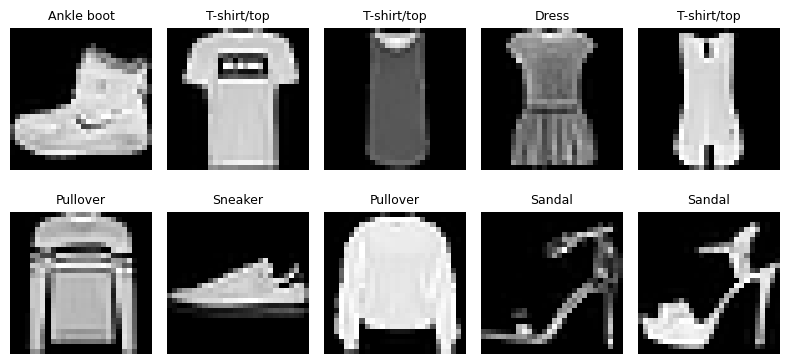

In [4]:

# 학습 이미지 몇 장을 직접 눈으로 확인한다.
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(class_names[train_labels[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 전처리하기

이미지 픽셀 값은 원래 0~255 범위다.
모델이 안정적으로 학습하도록 0~1 범위로 바꾼다.

그리고 CNN 입력 모양에 맞게 채널 차원을 추가한다.


In [5]:

# astype("float32")는 정수 이미지를 실수형 숫자로 바꾼다.
# 255.0으로 나누면 픽셀 값이 0~1 범위가 된다.
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# CNN은 (샘플 수, 높이, 너비, 채널 수) 모양을 기대한다.
# Fashion-MNIST는 흑백 이미지라 채널 수가 1이다.
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

print("전처리 후 train_images:", train_images.shape)
print("전처리 후 test_images:", test_images.shape)


전처리 후 train_images: (60000, 28, 28, 1)
전처리 후 test_images: (10000, 28, 28, 1)


## CNN 모델 만들기

9장에서 배운 기본 층을 다시 사용한다.

```text
Conv2D -> MaxPooling2D -> Conv2D -> MaxPooling2D -> Flatten -> Dense
```


In [6]:

model = tf.keras.Sequential([
    # 입력 이미지 한 장의 모양은 28x28 흑백, 즉 (28, 28, 1)이다.
    layers.Input(shape=(28, 28, 1)),

    # Conv2D는 작은 필터를 움직이며 이미지 특징을 찾는다.
    # filters=16은 특징 지도 16개를 만든다는 뜻이다.
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),

    # MaxPooling2D는 중요한 특징만 남기고 이미지 크기를 줄인다.
    layers.MaxPooling2D((2, 2)),

    # 두 번째 Conv2D는 앞 층보다 조금 더 많은 특징을 찾도록 32개 필터를 사용한다.
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Flatten은 2차원 특징 지도를 Dense 층에 넣기 위해 1차원으로 펼친다.
    layers.Flatten(),

    # Dense 층은 펼쳐진 특징을 보고 최종 판단을 준비한다.
    layers.Dense(64, activation="relu"),

    # Fashion-MNIST는 클래스가 10개이므로 출력도 10개다.
    # softmax는 10개 클래스 각각의 가능성을 출력한다.
    layers.Dense(10, activation="softmax"),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:

# compile은 학습 방법을 정하는 단계다.
# optimizer="adam": 가중치를 업데이트하는 방법
# loss="sparse_categorical_crossentropy": 정수 라벨을 쓰는 다중분류 loss
# metrics=["accuracy"]: 학습 중 정확도도 함께 보겠다는 뜻
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [8]:

# CPU 환경을 고려해 epoch는 작게 둔다.
# 목적은 최고 정확도가 아니라 CNN 흐름 복습이다.
history = model.fit(
    train_images,
    train_labels,
    epochs=2,
    batch_size=128,
    validation_split=0.2,
    verbose=1,
)


Epoch 1/2



  1/375 ━━━━━━━━━━━━━━━━━━━━ 7:24 1s/step - accuracy: 0.1719 - loss: 2.2866


  6/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2964 - loss: 2.2074


 12/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3440 - loss: 2.0995


 17/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3714 - loss: 2.0023

...


356/375 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8642 - loss: 0.3894


361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8643 - loss: 0.3892


367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8643 - loss: 0.3890


373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8644 - loss: 0.3887


375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8674 - loss: 0.3737 - val_accuracy: 0.8753 - val_loss: 0.3521


In [9]:

# 테스트 데이터로 모델을 평가한다.
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print("테스트 loss:", test_loss)
print("테스트 accuracy:", test_accuracy)


테스트 loss: 0.36889031529426575
테스트 accuracy: 0.8659999966621399


## 예측 결과 확인하기

모델이 어떤 이미지를 어떻게 예측하는지 직접 보자.
정확도 숫자만 보는 것보다 실제 이미지를 함께 보는 습관이 중요하다.


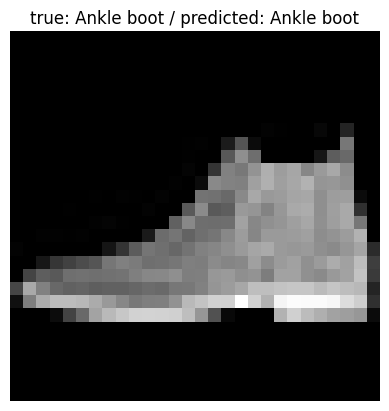

클래스별 예측 확률:
T-shirt/top : 0.0000
Trouser     : 0.0000
Pullover    : 0.0000
Dress       : 0.0000
Coat        : 0.0000
Sandal      : 0.0202
Shirt       : 0.0001
Sneaker     : 0.1078
Bag         : 0.0012
Ankle boot  : 0.8707


In [10]:

# 테스트 이미지 중 하나를 고른다.
image_index = 0
selected_image = test_images[image_index]
true_label = test_labels[image_index]

# model.predict는 각 클래스에 대한 가능성 10개를 반환한다.
prediction = model.predict(selected_image.reshape(1, 28, 28, 1), verbose=0)
predicted_label = int(np.argmax(prediction))

plt.imshow(selected_image.reshape(28, 28), cmap="gray")
plt.title(f"true: {class_names[true_label]} / predicted: {class_names[predicted_label]}")
plt.axis("off")
plt.show()

print("클래스별 예측 확률:")
for name, prob in zip(class_names, prediction[0]):
    print(f"{name:12s}: {prob:.4f}")


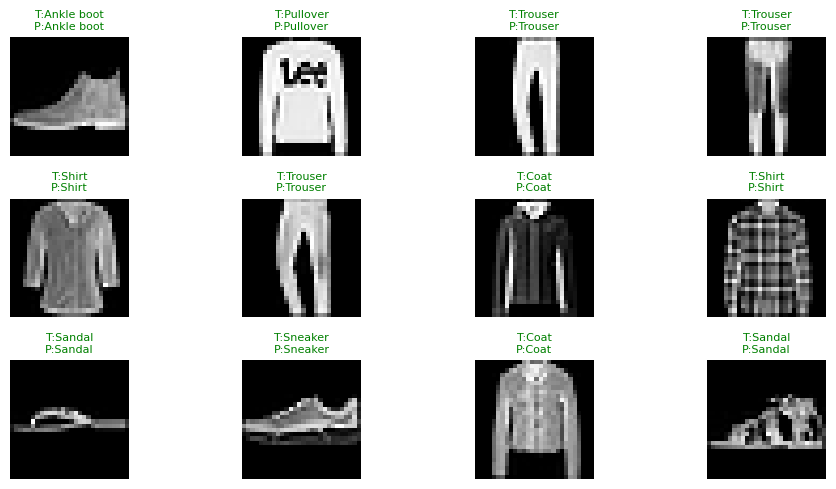

In [11]:

# 여러 장을 한 번에 예측해보고 맞았는지 틀렸는지 색으로 표시한다.
num_images = 12
predictions = model.predict(test_images[:num_images], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 5))
for i in range(num_images):
    plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap="gray")
    color = "green" if predicted_labels[i] == test_labels[i] else "red"
    title = f"T:{class_names[test_labels[i]]}\nP:{class_names[predicted_labels[i]]}"
    plt.title(title, color=color, fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 정리 퀴즈

아래 질문에 말로 답해보자.

```text
1. Fashion-MNIST 이미지 한 장의 입력 모양은?
2. 마지막 Dense가 10인 이유는?
3. sparse_categorical_crossentropy를 쓴 이유는?
4. Conv2D와 MaxPooling2D의 역할 차이는?
5. 예측 확률 10개 중 최종 클래스는 어떻게 고르는가?
```

이 질문에 답할 수 있다면 9장의 CNN 기본 흐름을 잘 복습한 것이다.
